# Licking EF — Licking vs Non-Licking (within on-nest, 3-band frequency)

Paper-active dCSFA-NMF model for separating Licking vs Non-Licking LFP windows, restricted to on-nest samples.

* Final model: `Maternal_model_lick_Onnest_C_only_Dec19_v1.pt`
* Hyperparameters from LOO validation (sup_weight=0.07, n_epochs=400, batch_size=256, h=64, seed=2025)
* Stage backproject artifact: `LickingEF_3band.xlsx`

In [1]:
# Allow imports from ../src
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.join(_repo_root, "src") not in sys.path:
    sys.path.insert(0, os.path.join(_repo_root, "src"))

from electome.data_utils import create_period_dataset, create_split_dataset, clean_mouse_id
from electome.training import run_loo_cv, train_final_model
from electome.analysis import process_W_nmf_dual_filter
from electome.viz import create_bar_heatmap_selective
from electome.workflow import validate_on_ELS, run_circos_prep, run_stage_backproject
from electome.sara_requests import sara_pup_retrieval

from electome.dCSFA_NMF_Ver1 import dCSFA_NMF as DCSFA_VER1


## Section 1. Data loading and processing

Filter to on-nest windows only (`onnest_raw == 1`), then split into C/E groups via `create_split_dataset`. Label = `licking`.

In [2]:
FULL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P3_onnest_lick/full_onnest_lick_Trim.pkl"

# Canonical (post-clean_mouse_id) target ids
C_MOUSE_IDS = ["C7ELS11", "C2ELS18", "C5ELS20", "C7ELS22",
                "C1ELS32", "C5ELS40", "C6ELS42", "C7ELS45"]
E_MOUSE_IDS = ["E2ELS3", "E1ELS33", "E3ELS37", "E4ELS39", "E5ELS41", "E6ELS44"]
ALL_TARGET_MOUSE_IDS = C_MOUSE_IDS + E_MOUSE_IDS

with open(FULL_DATA_FILE, "rb") as f:
    full_dict = pickle.load(f)

# Filter to on-nest windows (within-on-nest licking classifier)
condition = (full_dict["onnest_raw"] == 1)

datasets = create_split_dataset(
    full_dict, condition, ALL_TARGET_MOUSE_IDS, y_arg="licking",
)
train_c = {
    "X": datasets["C"]["X"],
    "y": datasets["C"]["y"],
    "y_intercept": datasets["C"]["mouse_ids"],
    "y_sampling": datasets["C"]["y_sampling"],
}
test_e = {
    "X": datasets["E"]["X"],
    "y": datasets["E"]["y"],
    "y_intercept": datasets["E"]["mouse_ids"],
}
print(f"Train C : X={train_c['X'].shape}, mice={sorted(set(train_c['y_intercept']))}")
print(f"Test E  : X={test_e['X'].shape},  mice={sorted(set(test_e['y_intercept']))}")


Train C : X=(13432, 108), mice=['C1ELS32', 'C2ELS18', 'C5ELS20', 'C5ELS40', 'C6ELS42', 'C7ELS11', 'C7ELS22', 'C7ELS45']
Test E  : X=(9727, 108),  mice=['E1ELS33', 'E2ELS3', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']


## Section 2. LOO training

In [3]:
SEED = 2025
N_EPOCHS = 400
N_PRE_EPOCHS = 100
NMF_MAX_ITER = 500
BATCH_SIZE = 256
LR = 1e-3

# Note: the legacy notebook listed these hyperparameters as UPPERCASE
# top-level constants rather than dict entries. The dict form here is
# numerically identical (sup_weight=0.07, h=64, etc.).
MODEL_PARAMS = {
    "n_components": 10,
    "n_sup_networks": 1,
    "optim_name": "SGD",
    "recon_loss": "MSE",
    "sup_recon_weight": 0.0,
    "sup_weight": 0.07,
    "phi_weight": 0.0,
    "n_intercepts": 1,
    "useDeepEnc": True,
    "h": 64,
    "sup_recon_type": "Residual",
    "feature_groups": None,
    "group_weights": None,
    "fixed_corr": "Positive",
    "momentum": 0.9,
    "sup_smoothness_weight": 1,
}

loo = run_loo_cv(
    train_c["X"], train_c["y"], train_c["y_intercept"],
    model_params=MODEL_PARAMS,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    n_pre_epochs=N_PRE_EPOCHS, nmf_max_iter=NMF_MAX_ITER,
    seed=SEED, n_jobs=4,
    dCSFA_NMF_class=DCSFA_VER1,
)
print(loo.summary())
print()
print(loo.per_mouse_table())


Pretraining NMF...
Identifying predictive components for network 0
Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 0 with auc 0.7582437611920185 for sup net 0 using constraint positive correlation
Selecting network: 0 with auc 0.7684081480125683 for sup net 0 using constraint positive correlation
Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 2 with auc 0.7772791733644511 for sup net 0 using constraint positive correlation


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
  0%|          | 0/100 [00:00<?,

Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 0 with auc 0.768696283860765 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:12<00:00,  8.15it/s]
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
  0%|          | 0/100 [00:00<?, ?it/s]
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergenc

Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 0 with auc 0.7811744347113735 for sup net 0 using constraint positive correlation
Pretraining NMF...
Identifying predictive components for network 0


...

Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 0 with auc 0.7476902278872152 for sup net 0 using constraint positive correlation


 90%|█████████ | 90/100 [00:11<00:01,  8.27it/s]
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
 92%|█████████▏| 92/100 [00:11<00:01,  7.88it/s]

Pretraining NMF...
Identifying predictive components for network 0
Selecting network: 0 with auc 0.7759232578341844 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:13<00:00,  7.62it/s]

LOO CV (n=8 mice): AUC = 0.7812 ± 0.0527   Wilcoxon p = 0.007812  ** (p < 0.01)   [wall time 4.2 min]

Mouse        AUC        N        Pos    Neg    phi       
---------------------------------------------------------
C1ELS32      0.4947     1718     85     1633   1.2081    
C2ELS18      0.8902     1061     43     1018   0.4680    
C5ELS20      0.6694     2185     45     2140   1.0283    
C5ELS40      0.8458     2169     137    2032   0.7051    
C6ELS42      0.6838     1465     75     1390   0.6615    
C7ELS11      0.9112     1336     28     1308   0.0345    
C7ELS22      0.8732     2626     23     2603   0.5674    
C7ELS45      0.8811     872      37     835    0.3246    


## Section 3. Full training (paper model)

In [4]:
MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"
MODEL_STATE_DICT = "Maternal_sd_lick_Onnest_C_only_Dec19_v1.pt"

model = train_final_model(
    train_c["X"], train_c["y"], train_c["y_sampling"],
    model_params=MODEL_PARAMS,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    n_pre_epochs=N_PRE_EPOCHS, nmf_max_iter=NMF_MAX_ITER,
    seed=SEED,
    save_to=MODEL_SAVE_FILE,
    state_dict_to=MODEL_STATE_DICT,
    dCSFA_NMF_class=DCSFA_VER1,
)
train_aucs = [auc[0] for auc in model.train_auc_hist]
print(f"Paper model saved : {MODEL_SAVE_FILE}")
print(f"  Final train AUC : {train_aucs[-1]:.4f}")


Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████| 10/10 [00:00<00:00, 153.49it/s]


Selecting network: 0 with auc 0.7791124292307811 for sup net 0 using constraint positive correlation


100%|██████████| 100/100 [00:11<00:00,  8.79it/s]


Paper model saved : Maternal_model_lick_Onnest_C_only_Dec19_v1.pt
  Final train AUC : 0.7843


## Section 4. Circos plot

In [5]:
df_circos = run_circos_prep(
    model, full_dict,
    output_csv="LickingEF_3band_circos_input.csv",
    k=0, threshold_ratio=0.8,
)


  Circos input written: LickingEF_3band_circos_input.csv  (33 features at threshold_ratio=0.8)


## Section 5. Elements selection

absolute intensity range: 0 - 2.034576
relative uniqueness range: 0.0000 - 0.4110


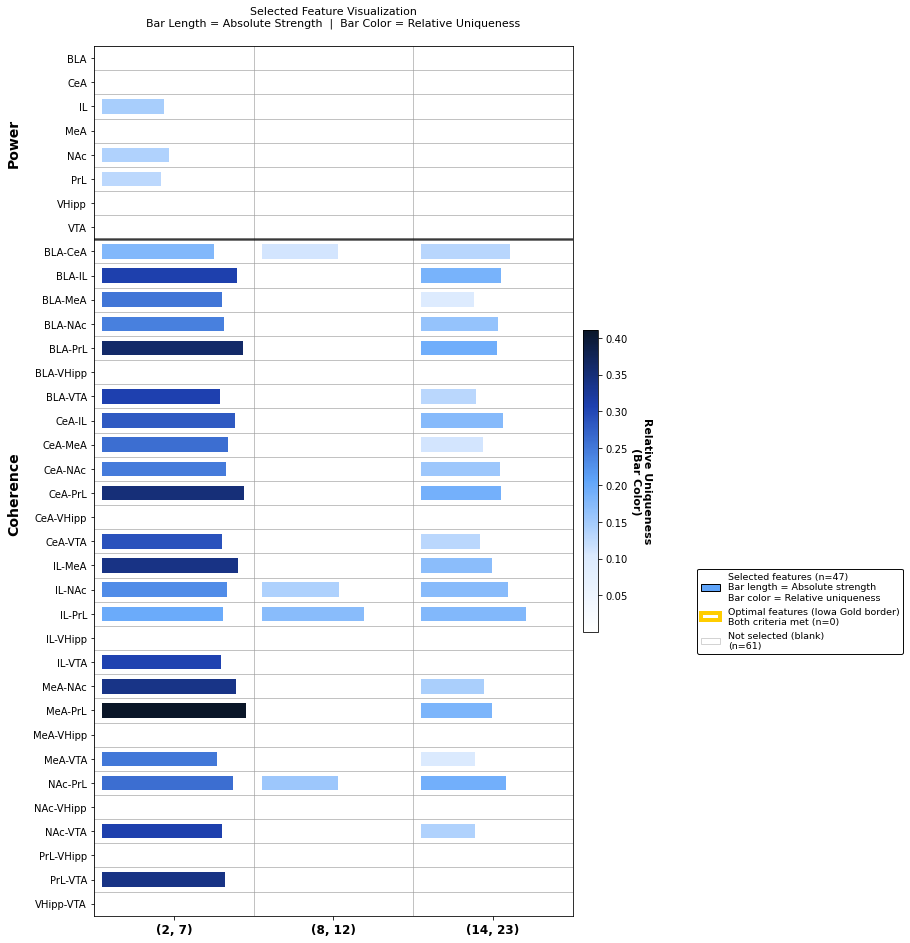

Bar heatmap saved : LickingEF_3band_bar_heatmap.png  (0 optimal features)


In [6]:
abs_cut, rel_cut, both_cut, abs_full, rel_full = process_W_nmf_dual_filter(
    model.get_W_nmf(), full_dict,
    abs_cum_ratio=0.9, rel_val=0.5,
    verbose=False,
)
fig = create_bar_heatmap_selective(abs_full, abs_cut, rel_full, rel_cut, both_cut)
fig.savefig("LickingEF_3band_bar_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Bar heatmap saved : LickingEF_3band_bar_heatmap.png  "
      f"({(~both_cut.isna()).sum().sum()} optimal features)")


## Section 6. Validation on ELS group

In [7]:
els = validate_on_ELS(model, {"E mice (within-on-nest licking)": test_e})
print(els.summary())


VALIDATION ON ELS GROUP
  E mice (within-on-nest licking): AUC = 0.7061 ± 0.0795  (n=6 mice)   Wilcoxon p = 0.07812  n.s.


## Section 8. Additional backprojections (Sara's request)

Only one Sara request applies to this task: pup-retrieval loading scores for the within-on-nest licking model.

In [8]:
PUP_RETRIEVAL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P4_pup_retrieval_detail.pkl"

sara_pup_retrieval(
    model,
    pup_retrieval_data_file=PUP_RETRIEVAL_DATA_FILE,
    c_mouse_ids=["C6ELS9"] + C_MOUSE_IDS,
    e_mouse_ids=E_MOUSE_IDS,
    output_xlsx="Licking_pups_3band.xlsx",
)


  Sara pup retrieval written: Licking_pups_3band.xlsx  (9 mice, Individual + Summary sheets)
